# Financial Fraud Detection Using Machine Learning

**Dataset:** `Synthetic_Financial_datasets_log.csv`  
**Target variable:** `isFraud`  
**Models:** Logistic Regression, KNN, Decision Tree, Random Forest

### Project aim

The aim of this project is to investigate whether machine learning classification models can identify fraudulent financial transactions.

The project follows a complete ML workflow:

1. Load and understand the dataset
2. Clean and inspect the data
3. Explore the data
4. Prepare features and target
5. Handle class imbalance
6. Split data into training, validation and test sets
7. Train four machine learning models
8. Evaluate their performance
9. Compare the models
10. Analyse errors
11. Select the best model based on the evidence
12. Document limitations and possible improvements

Note : Accuracy is not treated as the primary success metric because fraud is a highly imbalanced problem. Precision, recall, F1, PR-AUC, false positives, false negatives and expected cost are more informative.


## 2. Dataset Background

The dataset is the **PaySim synthetic financial transaction dataset**. It represents mobile-money transactions and contains legitimate and fraudulent transactions.

The dataset contains transaction information such as:

- transaction type
- transaction amount
- original account balance
- destination account balance
- transaction time
- fraud label

The target variable is:

`isFraud`

where:

- `0` = legitimate transaction
- `1` = fraudulent transaction

### Research limitation

The dataset is synthetic. Therefore, strong results on this dataset do not automatically mean the model would perform equally well on real banking transactions.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [2]:
df = pd.read_csv("Synthetic_Financial_datasets_log.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 6362620
Columns: 11


In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [5]:
df.head(6)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0,0


In [6]:
df.shape

(6362620, 11)

In [7]:
print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Data types:


,dtype
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


# Check missing values

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

# Check duplicate rows

In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


# Target Variable Analysis

In [16]:
target_counts = df["isFraud"].value_counts()
target_counts

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [17]:
target_percent = df["isFraud"].value_counts(normalize=True) * 100
target_percent

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

# Target distribution

In [18]:
summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(4)
})
summary.index = ["Legitimate (0)", "Fraud (1)"]
summary

,Count,Percentage
Legitimate (0),6354407,99.8709
Fraud (1),8213,0.1291


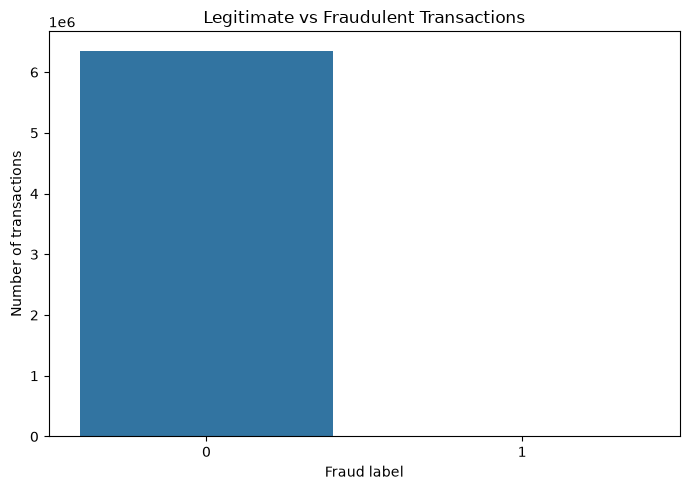

In [19]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="isFraud")
plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Fraud label")
plt.ylabel("Number of transactions")
plt.tight_layout()
plt.show()

# Explore fraud by transaction type

In [20]:
type_summary = (
    df.groupby("type", observed=True)["isFraud"]
      .agg(["count", "sum", "mean"])
      .rename(columns={"sum": "fraud_count", "mean": "fraud_rate"})
      .sort_values("fraud_rate", ascending=False)
)
type_summary["fraud_rate_pct"] = type_summary["fraud_rate"] * 100
type_summary

,count,fraud_count,fraud_rate,fraud_rate_pct
type,,,,
TRANSFER,532909,4097,0.007688,0.768799
CASH_OUT,2237500,4116,0.001840,0.183955
CASH_IN,1399284,0,0.000000,0.000000
DEBIT,41432,0,0.000000,0.000000
PAYMENT,2151495,0,0.000000,0.000000


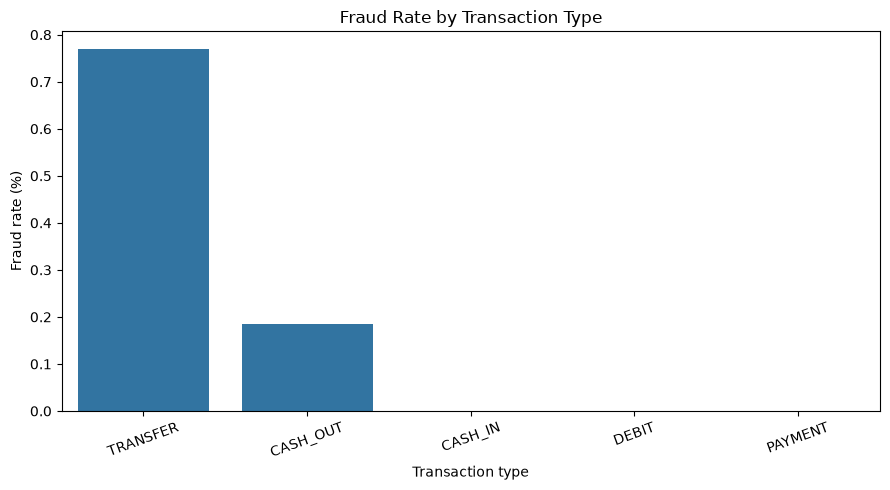

In [21]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=type_summary.reset_index(),
    x="type",
    y="fraud_rate_pct"
)
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction type")
plt.ylabel("Fraud rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Explore transaction amounts

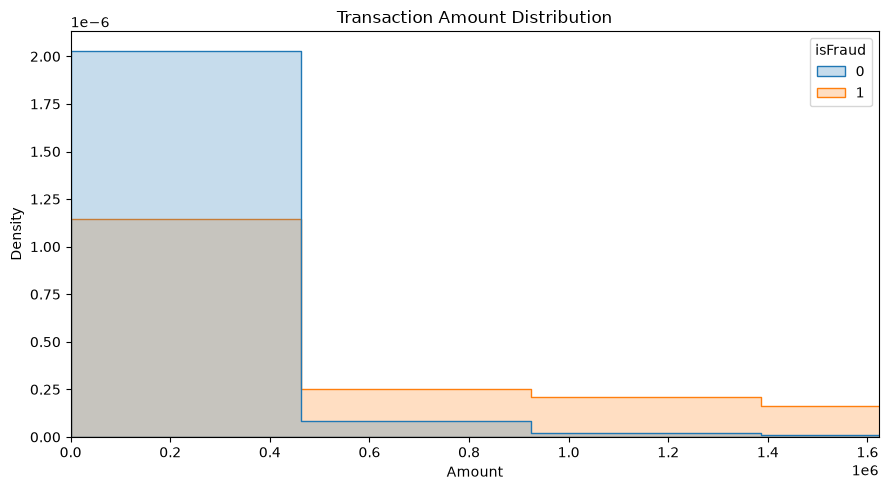

In [24]:
plot_sample = df.sample(n=min(200_000, len(df)), random_state=42)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=plot_sample,
    x="amount",
    hue="isFraud",
    bins=80,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.xlim(0, plot_sample["amount"].quantile(0.99))
plt.tight_layout()
plt.show()

# Explore fraud over time

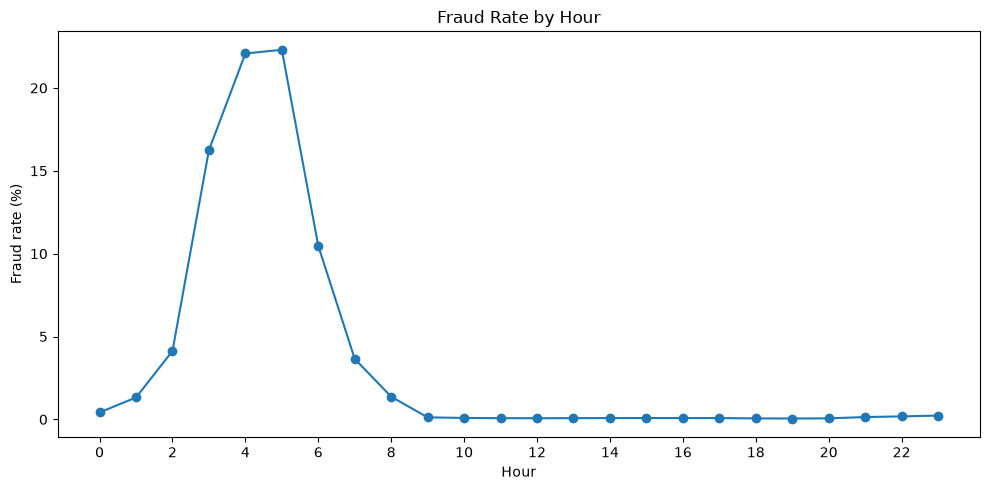

In [25]:
df["hour"] = df["step"] % 24
df["day"] = df["step"] // 24

fraud_by_hour = df.groupby("hour")["isFraud"].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(fraud_by_hour.index, fraud_by_hour.values, marker="o")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud rate (%)")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

# Feature engineering
- `step`: transaction time index
- `hour`: hour within a 24-hour cycle
- `day`: day index
- `amount`: transaction amount
- `log_amount`: log-transformed amount
- `oldbalanceOrg`: origin balance before the transaction
- `oldbalanceDest`: destination balance before the transaction
- `amount_to_origin_balance`: transaction amount relative to the origin balance
- `amount_to_destination_balance`: transaction amount relative to the destination balance
- `type`: transaction type


In [26]:
model_df = df.copy()

model_df["log_amount"] = np.log1p(model_df["amount"])
model_df["amount_to_origin_balance"] = (
    model_df["amount"] / (model_df["oldbalanceOrg"] + 1.0)
)
model_df["amount_to_destination_balance"] = (
    model_df["amount"] / (model_df["oldbalanceDest"] + 1.0)
)

feature_columns = [
    "step",
    "hour",
    "day",
    "type",
    "amount",
    "log_amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "amount_to_origin_balance",
    "amount_to_destination_balance"
]

target_column = "isFraud"

X = model_df[feature_columns].copy()
y = model_df[target_column].copy()

print("Features:", feature_columns)
print("X shape:", X.shape)

Features: ['step', 'hour', 'day', 'type', 'amount', 'log_amount', 'oldbalanceOrg', 'oldbalanceDest', 'amount_to_origin_balance', 'amount_to_destination_balance']
X shape: (6362620, 10)


# Train-test split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", f"{len(X_train):,}")
print("Testing rows:", f"{len(X_test):,}")

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training rows: 5,090,096
Testing rows: 1,272,524

Training target distribution:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Testing target distribution:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


# Handle class imbalance

In [30]:
train_df = X_train.copy()
train_df["isFraud"] = y_train.values

fraud_train = train_df[train_df["isFraud"] == 1]
legitimate_train = train_df[train_df["isFraud"] == 0]

n_legitimate = min(len(legitimate_train), len(fraud_train) * 5)
legitimate_sample = legitimate_train.sample(
    n=n_legitimate,
    random_state=42
)

train_balanced = pd.concat([fraud_train, legitimate_sample])
train_balanced = train_balanced.sample(frac=1, random_state=42)

X_train_balanced = train_balanced.drop(columns="isFraud")
y_train_balanced = train_balanced["isFraud"]

print("Original training rows:", f"{len(X_train):,}")
print("Balanced training rows:", f"{len(X_train_balanced):,}")
print("\nBalanced training distribution:")
print(y_train_balanced.value_counts())

Original training rows: 5,090,096
Balanced training rows: 39,420

Balanced training distribution:
isFraud
0    32850
1     6570
Name: count, dtype: int64


# Preprocessing

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_features = [
    "step", "hour", "day", "amount", "log_amount",
    "oldbalanceOrg", "oldbalanceDest",
    "amount_to_origin_balance", "amount_to_destination_balance"
]
categorical_features = ["type"]

numeric_preprocessor_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_scaled = ColumnTransformer([
    ("num", numeric_preprocessor_scaled, numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_preprocessor, numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])

# Logistic Regression Model

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time 

logistic_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

start = time.time()
logistic_model.fit(X_train_balanced, y_train_balanced)
print(f"Training time: {time.time() - start:.2f} seconds")

C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training time: 0.56 seconds


# Decision Tree

In [41]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ))
])

start = time.time()
decision_tree_model.fit(X_train_balanced, y_train_balanced)
print(f"Training time: {time.time() - start:.2f} seconds")

Training time: 0.48 seconds


# Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

start = time.time()
random_forest_model.fit(X_train_balanced, y_train_balanced)
print(f"Training time: {time.time() - start:.2f} seconds")

Training time: 3.25 seconds


# XGBoost

In [47]:
!pip install xgboost


   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.3/48.9 MB 4.8 MB/s eta 0:00:10
   - -------------------------------------- 2.1/48.9 MB 4.3 MB/s eta 0:00:11
   -- ------------------------------------- 3.1/48.9 MB 4.5 MB/s eta 0:00:11
   --- ------------------------------------ 4.2/48.9 MB 4.5 MB/s eta 0:00:10
   ---- ----------------------------------- 5.2/48.9 MB 4.6 MB/s eta 0:00:10
   ---- ----------------------------------- 6.0/48.9 MB 4.4 MB/s eta 0:00:10
   ----- ---------------------------------- 6.8/48.9 MB 4.3 MB/s eta 0:00:10
   ------ --------------------------------- 7.6/48.9 MB 4.2 MB/s eta 0:00:10
   ------ --------------------------------- 8.4/48.9 MB 4.1 MB/s eta 0:00:10
   ------- -------------------------------- 9.2/48.9 MB 4.2 MB/s eta 0:00:10
   -------- ------------------------------- 10.2/48.9 MB 4.2 MB/s eta 0:00:10
   -------- 

In [49]:
import xgboost
from xgboost import XGBClassifier

fraud_count = (y_train_balanced == 1).sum()
legitimate_count = (y_train_balanced == 0).sum()
scale_pos_weight = legitimate_count / fraud_count

xgboost_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

start = time.time()
xgboost_model.fit(X_train_balanced, y_train_balanced)
print(f"Training time: {time.time() - start:.2f} seconds")

Training time: 1.04 seconds


# Evaluate all models

In [51]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model
}

results = []
probabilities = {}
predictions = {}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)

    probabilities[name] = y_prob
    predictions[name] = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
results_df.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Random Forest,0.999557,0.744893,0.998783,0.853354,0.999836,0.998547
1,XGBoost,0.999522,0.730307,0.998783,0.843702,0.999827,0.998690
2,Decision Tree,0.998695,0.497273,0.998783,0.663969,0.999371,0.977650
3,Logistic Regression,0.868025,0.009023,0.930006,0.017872,0.971256,0.221507


In [52]:
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,Random Forest,0.9996,0.7449,0.9988,0.8534,0.9998,0.9985
3,XGBoost,0.9995,0.7303,0.9988,0.8437,0.9998,0.9987
1,Decision Tree,0.9987,0.4973,0.9988,0.6640,0.9994,0.9776
0,Logistic Regression,0.8680,0.0090,0.9300,0.0179,0.9713,0.2215


# Classification reports

In [53]:
for name in models:
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test,
        predictions[name],
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    ))

Logistic Regression
              precision    recall  f1-score   support

  Legitimate     0.9999    0.8679    0.9293   1270881
       Fraud     0.0090    0.9300    0.0179      1643

    accuracy                         0.8680   1272524
   macro avg     0.5045    0.8990    0.4736   1272524
weighted avg     0.9986    0.8680    0.9281   1272524

Decision Tree
              precision    recall  f1-score   support

  Legitimate     1.0000    0.9987    0.9993   1270881
       Fraud     0.4973    0.9988    0.6640      1643

    accuracy                         0.9987   1272524
   macro avg     0.7486    0.9987    0.8317   1272524
weighted avg     0.9993    0.9987    0.9989   1272524

Random Forest
              precision    recall  f1-score   support

  Legitimate     1.0000    0.9996    0.9998   1270881
       Fraud     0.7449    0.9988    0.8534      1643

    accuracy                         0.9996   1272524
   macro avg     0.8724    0.9992    0.9266   1272524
weighted avg     0.9997   

# Confusion Matrix for Logistic Regression

Highest F1-score model in this experiment: Random Forest


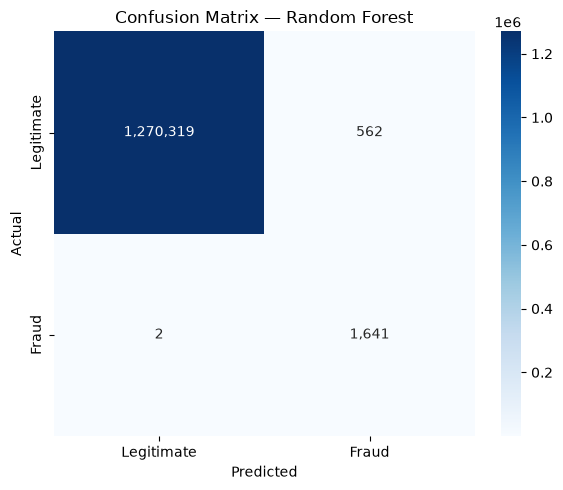

In [54]:
from sklearn.metrics import confusion_matrix

best_model_name = results_df.iloc[0]["Model"]
print("Highest F1-score model in this experiment:", best_model_name)

cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC-AUC Comparison

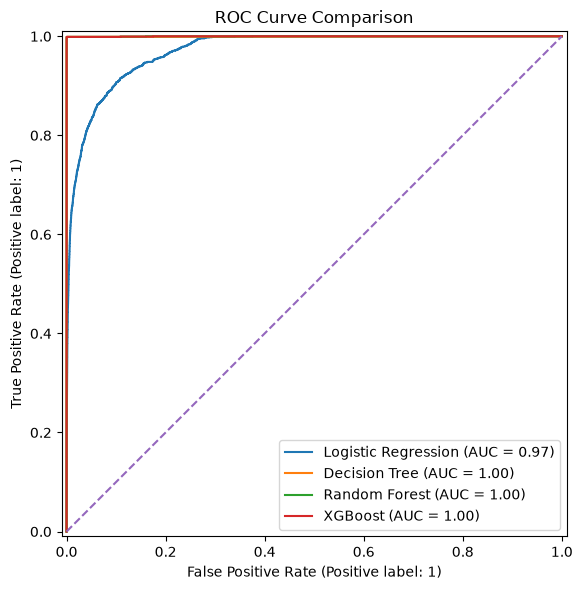

In [55]:
plt.figure(figsize=(9, 6))

for name in models:
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[name],
        name=name,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

# Precision-Recall comparison

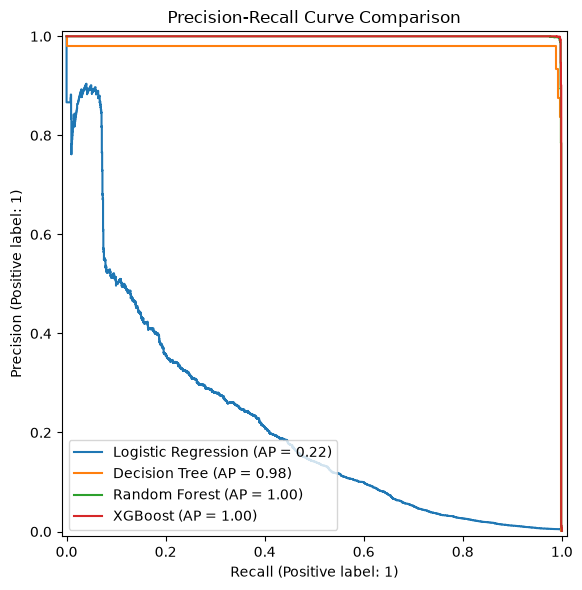

In [56]:
plt.figure(figsize=(9, 6))

for name in models:
    PrecisionRecallDisplay.from_predictions(
        y_test,
        probabilities[name],
        name=name,
        ax=plt.gca()
    )

plt.title("Precision-Recall Curve Comparison")
plt.tight_layout()
plt.show()

# Model selection

The model is **not** selected using accuracy alone.

The primary comparison is F1-score, supported by recall, precision, PR-AUC and ROC-AUC. However, the final deployment decision should also consider interpretability, computational cost and maintainability.

If XGBoost has only a small F1 improvement over Random Forest, Random Forest may be selected for deployment because it is easier to explain and maintain. If the performance improvement is substantial, XGBoost may be the more appropriate choice.

In [57]:
# Compare the top two models by F1-score.
results_df[["Model", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]]

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,Random Forest,0.744893,0.998783,0.853354,0.999836,0.998547
3,XGBoost,0.730307,0.998783,0.843702,0.999827,0.998690
1,Decision Tree,0.497273,0.998783,0.663969,0.999371,0.977650
0,Logistic Regression,0.009023,0.930006,0.017872,0.971256,0.221507


# Random Forest feature importance

Feature importance helps explain which variables contribute most to the Random Forest's decisions. It is an explanatory tool, not proof of causality.

In [58]:
rf = random_forest_model.named_steps["model"]
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
7,num__amount_to_origin_balance,0.419355
5,num__oldbalanceOrg,0.115978
8,num__amount_to_destination_balance,0.081065
12,cat__type_PAYMENT,0.059656
3,num__amount,0.051625
4,num__log_amount,0.051052
9,cat__type_CASH_IN,0.048927
13,cat__type_TRANSFER,0.041314
10,cat__type_CASH_OUT,0.036804
1,num__hour,0.029653


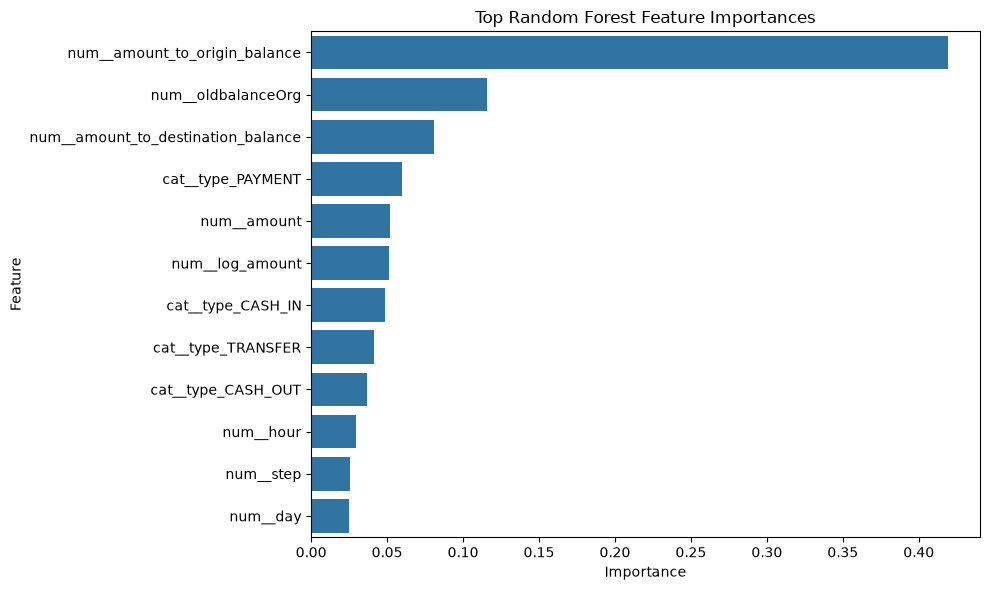

In [59]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(12),
    x="Importance",
    y="Feature"
)
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Error analysis

A fraud model should be evaluated not only by its score but also by the types of errors it makes.

- **False negative:** Fraud predicted as legitimate. This is a missed fraud case.
- **False positive:** Legitimate transaction predicted as fraud. This creates an investigation.

In a real deployment, the classification threshold should be chosen using the organization's relative cost of these two errors rather than assuming 0.50 is universally optimal.

In [60]:
selected_for_analysis = best_model_name
pred = predictions[selected_for_analysis]

false_negatives = ((y_test == 1) & (pred == 0)).sum()
false_positives = ((y_test == 0) & (pred == 1)).sum()
true_positives = ((y_test == 1) & (pred == 1)).sum()
true_negatives = ((y_test == 0) & (pred == 0)).sum()

error_summary = pd.DataFrame({
    "Outcome": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Count": [true_negatives, false_positives, false_negatives, true_positives]
})
error_summary

,Outcome,Count
0,True Negative,1270319
1,False Positive,562
2,False Negative,2
3,True Positive,1641


# Save the deployment model

In [63]:
import joblib

DEPLOY_MODEL_NAME = "Random Forest"

if DEPLOY_MODEL_NAME not in models:
    raise ValueError("DEPLOY_MODEL_NAME must match one of the trained models.")

deployment_model = models[DEPLOY_MODEL_NAME]

artifact = {
    "model": deployment_model,
    "model_name": DEPLOY_MODEL_NAME,
    "feature_columns": feature_columns,
    "threshold": 0.50,
    "random_state": 42,
    "dataset": "PaySim synthetic financial transactions"
}

MODEL_PATH = "fraud_risk_model.pkl"
joblib.dump(artifact, MODEL_PATH)

print(f"Saved deployment artifact to: {MODEL_PATH}")

Saved deployment artifact to: fraud_risk_model.pkl


In [64]:
loaded_artifact = joblib.load(MODEL_PATH)
loaded_model = loaded_artifact["model"]

sample_X = X_test.iloc[:10].copy()
original_predictions = deployment_model.predict(sample_X)
loaded_predictions = loaded_model.predict(sample_X)

print("Model loaded successfully:", loaded_artifact["model_name"])
print("Predictions identical:", np.array_equal(original_predictions, loaded_predictions))

Model loaded successfully: Random Forest
Predictions identical: True


# Final findings

1. Fraud is a highly imbalanced class, so accuracy is not sufficient as the main metric.
2. Training only undersampling was used to improve the learning signal while preserving the natural test distribution.
3. Four models were compared: Logistic Regression, Decision Tree, Random Forest and XGBoost.
4. Feature engineering introduced temporal and transaction-to-balance ratio features.
5. The selected deployment model should be justified using F1-score, recall, precision, PR-AUC, interpretability and computational practicality—not simply the highest accuracy.
6. The model should be described as a fraud risk screening tool, not as proof that a transaction is fraudulent.
7. The dataset is synthetic, so real world deployment would require validation on representative production data, monitoring for distribution shift and threshold calibration.

# Limitations

- PaySim is synthetic rather than real banking data.
- Random train-test splitting does not reproduce a true future-time deployment scenario.
- Training uses undersampling, so some legitimate transactions are not used for model fitting.
- The 0.50 decision threshold is a baseline and is not optimized for a specific business cost.
- Feature importance does not establish causal relationships.